2000: S=1.7420, meanOPC=28.9157
3000: S=1.7940, meanOPC=29.7209
4000: S=1.8180, meanOPC=30.2939
5000: S=1.8330, meanOPC=30.5030
6000: S=1.8470, meanOPC=30.7255
7000: S=1.8530, meanOPC=30.9194
8000: S=1.8700, meanOPC=31.2599
9000: S=1.8780, meanOPC=31.3255
Saved: /Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/tooth model/plot_c/plot_c_tooth_Kg_vs_entropy.png


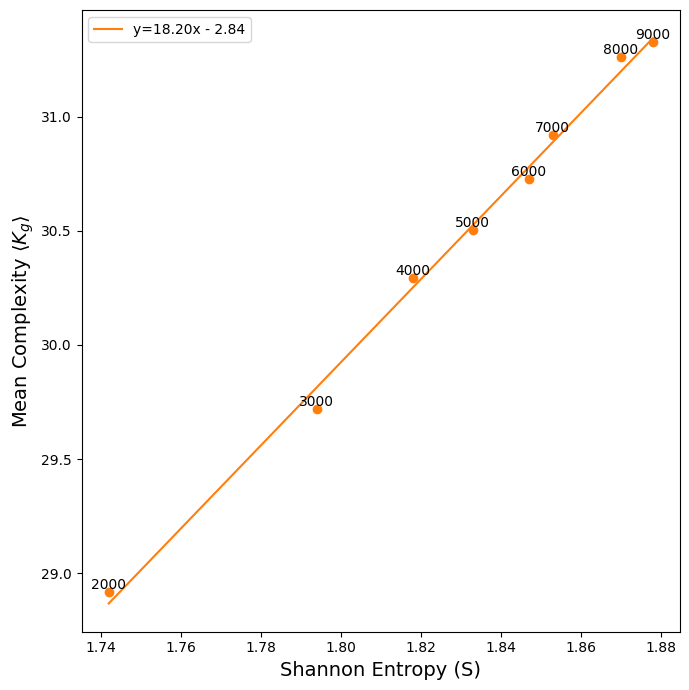

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

# ===================================
# Paths
# ===================================

data_dir = Path(
    "/Users/sam/Documents/Oxford/Physics/sloppiness/"
    "circadian/mut_project_updates/figures/tooth model/"
    "plot_c/plot_c_files/plot_d"
)

output_dir = Path(
    "/Users/sam/Documents/Oxford/Physics/sloppiness/"
    "circadian/mut_project_updates/figures/tooth model/plot_c"
)

# ===================================
# Load data from individual files
# ===================================

sizes = [2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000]

entropy_vals = []
kc_vals = []
labels = []

for n in sizes:
    entropy_file = data_dir / f"{n}_entropy.txt"
    mean_file = data_dir / f"{n}_meanOPC.txt"

    try:
        S = float(entropy_file.read_text().strip())
        K = float(mean_file.read_text().strip())

        entropy_vals.append(S)
        kc_vals.append(K)
        labels.append(str(n))

        print(f"{n}: S={S:.4f}, meanOPC={K:.4f}")

    except Exception as e:
        print(f"Skipping {n}: {e}")

entropy_vals = np.array(entropy_vals)
kc_vals = np.array(kc_vals)

# ===================================
# Plot
# ===================================

def make_plot(x, y, labels):
    m, b = np.polyfit(x, y, 1)
    fit_line = m * x + b

    sign = "-" if b < 0 else "+"
    eq_label = f'y={m:.2f}x {sign} {abs(b):.2f}'

    plt.figure(figsize=(7, 7))
    plt.scatter(x, y, color='tab:orange')
    plt.plot(x, fit_line, color='tab:orange', label=eq_label)

    for xi, yi, lbl in zip(x, y, labels):
        plt.text(xi, yi, lbl, fontsize=10, ha='center', va='bottom')

    plt.xlabel("Shannon Entropy (S)", fontsize=14)
    plt.ylabel(r"Mean Complexity $\langle K_g \rangle$", fontsize=14)

    plt.legend()
    plt.tight_layout()

    out_path = output_dir / "plot_c_tooth_Kg_vs_entropy.png"
    plt.savefig(out_path, dpi=300)
    print(f"Saved: {out_path}")

    plt.show()
    plt.close()

# ===================================
# Make plot
# ===================================

make_plot(entropy_vals, kc_vals, labels)